In [1]:
import os
import numpy as np            
import pandas as pd 
import scipy.stats as stats # For stats
import datetime #import date    # For dating the exported results 

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import statsmodels.formula.api as smf

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.transforms as transforms
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
from matplotlib.colors import LinearSegmentedColormap


## Set Paths: 

In [4]:
# Main path where the folders for this notebook and data lives 
path_main = os.path.split(os.getcwd())[0] # Where this code lives 
path_main

'/mnt/cup/labs/gomez/data/deaf/Manuscripts_Grants/Category_Manu_panels/Data_and_Code'

In [5]:
# Where we want our outputs exported to: 
plotspath = path_main + '/Notebook_Outputs/Outputs_Fig5C-F/'

# Create the folder (should not bother existing folder if it already exists)
os.makedirs(plotspath, exist_ok=True)

### Load Dataframe: 

In [6]:
path2data = path_main + '/Data/'
filename='Eyetracking_Data.csv'

df_ET = pd.read_csv(path2data+filename)
df_ET_full = df_ET
df_ET.head(10)

,Group,Sub,Bottom,Top,Lower_Bias,L,R,LR_Bias,STD_x,STD_y,avg_x,avg_y,STD_x_STD_y,Faces,Bodies,Scenes,Animacy,FaceBodies
0,C,CC66,1067,284,0.789785,688,664,0.508876,339.293612,199.135753,1314.058580,589.642012,1.703831,27.067669,33.834586,39.097744,1.557692,0.800000
1,C,CG11,1067,218,0.830350,673,612,0.523735,344.251449,189.554725,1283.596420,568.576109,1.816106,35.483871,18.548387,45.967742,1.175439,1.913043
2,C,CM88,1051,264,0.799240,669,646,0.508745,325.820387,186.162971,1293.530875,589.241673,1.750189,58.015267,20.610687,21.374046,3.678571,2.814815
3,C,CH11,1081,244,0.815849,710,615,0.535849,369.588896,149.681398,1263.751623,587.992604,2.469171,24.444444,32.592593,42.962963,1.327586,0.750000
4,C,CR88,1159,172,0.870774,717,614,0.538693,346.338720,160.202366,1274.660030,553.904132,2.161883,28.030303,28.787879,43.181818,1.315789,0.973684
5,C,CR33,1072,201,0.842105,653,620,0.512962,322.805293,152.156695,1284.055617,566.024823,2.121532,58.461538,23.076923,18.461538,4.416667,2.533333
6,C,CW77,950,87,0.916104,602,435,0.580521,353.962072,179.419320,1192.923047,453.167020,1.972820,43.925234,14.018692,42.056075,1.377778,3.133333
7,C,CB22,1100,268,0.804094,838,530,0.612573,313.292250,199.952334,1209.443640,608.356944,1.566835,27.692308,31.538462,40.769231,1.452830,0.878049
8,C,CC44,1137,178,0.864639,682,633,0.518631,336.818952,163.658960,1290.694221,561.994525,2.058054,52.713178,27.906977,19.379845,4.160000,1.888889
9,D,DB11,1210,161,0.882567,602,769,0.439096,363.271482,189.829865,1353.561926,524.338293,1.913669,50.359712,24.460432,25.179856,2.971429,2.058824


### Define Color Palette and Group order:

In [7]:
# Define Group order to be consistent throughout 
group_order = ['C','H','D']
group_names = ["C","HS","DS"]

# Define color pallate
custom_palette = ['cornflowerblue', '#ffcd8e', '#ff80ff']# Define custom color palette with group colors

# Creating the dictionary: {'C': 'cornflowerblue', 'H': '#ffcd8e', 'D': '#ff80ff'}
custom_palette_dict = dict(zip(group_order, custom_palette))
    
# Diverging colormap rangeing from control group color (blue) to DS group color (magenta)    
cmap_diverging_DC = LinearSegmentedColormap.from_list('diverging_DC',  ["cornflowerblue", "white", "#ff80ff"])

# Figure 5 // Panel C: Basic Visual Biases

### Vertical Visual Field Bias:

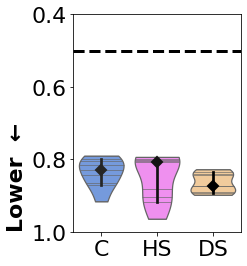

In [8]:
###########################
### Lower/Upper Bias    ###
###########################

refvalue=0.5

fig, ax = plt.subplots(figsize=(3,4))

# Plot Violins
sns.violinplot(df_ET,  x="Group", y="Lower_Bias", hue="Group", inner="stick", palette=custom_palette,hue_order=group_order, cut=0)#, hue="group")#, palette=my_palette[0:3])#, inner="points")

# Add Group Means
sns.pointplot(df_ET,  x="Group", y="Lower_Bias", hue="Group",
    estimator="median", 
    palette='dark:black',  # Color 4 mean point
    linestyle="none",      # Do not connect the points
    markers="D",           # Diamond marker for mean
    ax=ax)

# Aesthetics:
plt.ylim(0.4,1)
ax.axhline(y=0.5, color='k', linestyle='--', linewidth = 3)
plt.gca().invert_yaxis()
plt.ylabel('')
plt.xlabel('')
plt.ylabel('Lower  \u2190              ', fontweight ='bold', fontsize = 22)

plt.xticks(fontsize = 22)
plt.yticks(fontsize = 22)
plt.locator_params(axis='y', nbins=3)
ax.set(xticks=[0, 1, 2], xticklabels=['C','HS','DS'])

plt.savefig(plotspath+"Fig5_PanelC_Bias_bottomVtop_" + str(np.datetime64('today')) + ".png",format='png',dpi=300, bbox_inches='tight')
plt.show()


### Horizontal Visual Field Bias:

L/R Bias


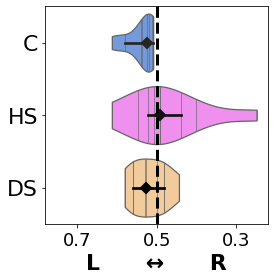

In [9]:
###########################
###  Left/Right Bias    ###
###########################

print("L/R Bias")
refvalue=0.5

fig, ax = plt.subplots(figsize=(4,4))

# Plot Violins
sns.violinplot(df_ET,  y="Group", x="LR_Bias", hue="Group", inner="stick", palette=custom_palette,hue_order=group_order, cut=0)#, hue="group")#, palette=my_palette[0:3])#, inner="points")

# Overlay group mean 
sns.pointplot(df_ET,  y="Group", x="LR_Bias", hue="Group",
    estimator="median", 
    palette='dark:black', # Color of mean point
    linestyle="none",     # no line connectors
    markers="D",          # Diamond marker for mean
    ax=ax)
 
plt.xlim(0.22,0.78)
ax.axvline(x=0.5, color='k', linestyle='--', linewidth = 3)
plt.xticks([0.3, 0.5, 0.7])
plt.ylabel('')
ax.invert_xaxis() # we want L on the left 
plt.xlabel('L      \u2194      R', fontweight ='bold', fontsize = 22)

ax.set(yticks=[0, 1, 2], yticklabels=['C','HS','DS'])

plt.xticks(fontsize = 18)
plt.yticks(fontsize = 22)

plt.savefig(plotspath+"Fig5_PanelC_Bias_LR_" + str(np.datetime64('today')) + ".png",format='png',dpi=300, bbox_inches='tight')
plt.show()

# Figure 5 // Panel E: LDA

### Separate labels from features and Z-scale the features:

In [10]:
# Separate numeric data from categorical labels
features = df_ET.drop(columns=['Group','Sub'])
labels = df_ET['Group']
                        
# Z-score features 
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### LDA

In [11]:
# Initialize LDA with 2 components (groups - 1)
lda = LinearDiscriminantAnalysis(n_components=2)

# Fit and Transform
lda_data = lda.fit_transform(scaled_features, labels) 

# Create a results DataFrame
lda_df = pd.DataFrame(data=lda_data, columns=['LD1', 'LD2'])
lda_df['Group'] = df_ET['Group'].values

# Check Silhouette Score
sil_score = silhouette_score(lda_data, lda_df['Group'])

print(f"Silhouette Score (LDA): {sil_score:.3f}")

Silhouette Score (LDA): 0.288


In [12]:
def add_confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = patches.Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                              facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

### Plot LD1 vs LD2 with group-ellipses and Silhouette score 

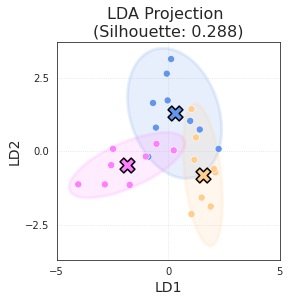

In [13]:
plt.figure(figsize=(4, 4))
sns.set_style("white")
ax = plt.gca()

# Scatter Plot individuals across LD1 and LD2 dimensions
sns.scatterplot(data=lda_df, x='LD1', y='LD2', hue='Group', palette=custom_palette_dict, s=50, ax=ax, zorder=3)

# Add Centroids and Ellipses for each group
for group_name, group_data in lda_df.groupby('Group'): 
    x, y = group_data['LD1'], group_data['LD2']
    color = custom_palette_dict[group_name]
    
    # Group centroid:
    cx, cy = x.mean(), y.mean()
    ax.scatter(cx, cy, color=color, s=220, marker='X', edgecolors='black', linewidth=1.5, zorder=5) # Large X
    
    # Confidence Ellipse (2 std):
    add_confidence_ellipse(x, y, ax, n_std=2.0, edgecolor=color, facecolor=color, 
                           alpha=0.15, linestyle='-', linewidth=3, zorder=2)

# Aesthetics:
plt.locator_params(axis='x', nbins=3)
plt.locator_params(axis='y', nbins=3)

plt.title(f'LDA Projection \n(Silhouette: {sil_score:.3f})',fontsize=16)
plt.grid(True, linestyle=':', alpha=0.6)

plt.gca().legend_.remove() # sns.move_legend(ax, "upper right", labels=['DS','HS','C'], title='Group')

ax.set_xlabel('LD1',fontsize=14)
ax.set_ylabel('LD2', fontsize=14)

plt.xlim(-5,5)
plt.ylim(-3.7,3.7)

plt.savefig(plotspath + 'Fig5_PanelE_LDA.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

### Print Loadings

In [14]:
feature_names = features.columns 

# Extract scalings/loadings
loadings_df = pd.DataFrame(lda.scalings_, index=feature_names, columns=['LD1', 'LD2'])

# Sort by Absolute Value
loadings_ld1_sorted = loadings_df.reindex(loadings_df['LD1'].abs().sort_values(ascending=False).index)

# Print:
print("--- Top Loadings for LD1 ---")
print(loadings_ld1_sorted[['LD1']])

# Now for LD2
loadings_ld2_sorted = loadings_df.reindex(loadings_df['LD2'].abs().sort_values(ascending=False).index)

print("\n--- Top Loadings for LD2 ---")
print(loadings_ld2_sorted[['LD2']])


--- Top Loadings for LD1 ---
                   LD1
L           -67.721976
Bottom       49.706224
R           -37.252983
Top          32.094415
LR_Bias      14.701224
avg_x         8.590807
Lower_Bias   -5.450965
avg_y        -2.043511
STD_x_STD_y   1.370405
STD_x        -1.257567
FaceBodies   -1.209559
Animacy       0.408889
STD_y        -0.396329
Faces         0.371858
Bodies       -0.295472
Scenes       -0.288145

--- Top Loadings for LD2 ---
                   LD2
L            80.456892
Bottom      -65.764196
R            50.741434
Top         -46.909008
LR_Bias       6.894324
avg_x         3.629993
Animacy      -3.575406
FaceBodies    2.916053
Bodies        2.248897
STD_y        -1.827783
STD_x_STD_y  -1.604608
avg_y         1.430740
Lower_Bias    1.371493
Scenes       -1.366054
STD_x         0.947013
Faces         0.421843


In [15]:
def plot_loadings(plotspath, ld_sorted, LD = 1, fig_size = [4,6]):
    # Create figure
    plt.figure(figsize=fig_size)

    colors = ['lightsteelblue' if val <= 0 else 'rosybrown' for val in ld_sorted["LD"+str(LD)]] 
    
    # Barplot
    sns.barplot(x=ld_sorted["LD"+str(LD)], y=ld_sorted.index,hue=ld_sorted.index, palette=colors)

    # Add vertical reference line at 0
    plt.axvline(0, color="black", linestyle="--", linewidth=1)

    # Labels and title
    plt.xlabel("LD" + str(LD) +" Loading")
    plt.ylabel("Feature")
    plt.title(f"Ranked LD{str(LD)} Scores")

    plt.tight_layout()
    
    plt.savefig(plotspath + 'Fig5_PanelE_LDA_Full_ranked_scores_LD' +str(LD)+ '.png', format='png', dpi=300, bbox_inches='tight')

    plt.show()

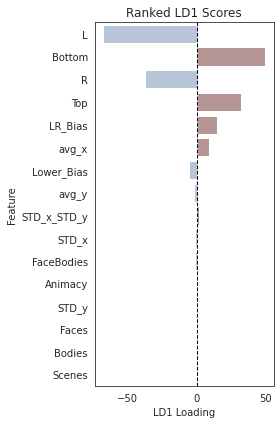

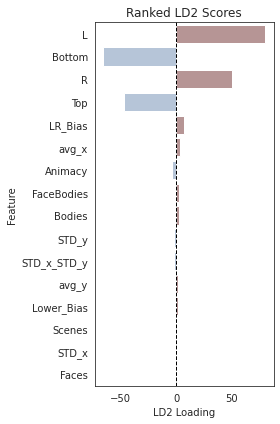

In [16]:
plot_loadings(plotspath, loadings_ld1_sorted, LD = 1 )
plot_loadings(plotspath, loadings_ld2_sorted, LD = 2 )

# Extra: LDA for Separating Group Pairs 
not included in paper, but shows seperability of group pairs rather than trying to separate all three groups from each other. 

In [17]:
def two_groups_LDA(df_ET, group_name_1, group_name_2, print_loadings = 0,z_score_features=0, selected_features=[]):
    
    df_ET_2G = df_ET[df_ET['Group'].isin([group_name_1,group_name_2])]
    features_2G = df_ET_2G.drop(columns=['Group','Sub']) #,'Bottom','Top','L','R'])
    
    if selected_features:
        features_2G = features_2G[selected_features]
        
    if z_score_features:   
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features_2G)
        features_2G = pd.DataFrame(scaled_features, columns=features_2G.columns, index=features_2G.index)
        print('With Z-score Normalization of features')

    # LDA
    lda_2G = LinearDiscriminantAnalysis(n_components=1)
    lda_data_2G = lda_2G.fit_transform(features_2G, df_ET_2G['Group'])
    
    # Create a results DataFrame
    lda_df_2G = pd.DataFrame(data=lda_data_2G, columns=['LD1'])
    lda_df_2G['Group'] = df_ET_2G['Group'].values
    
    # Silhouette Score
    sil_score_2G = silhouette_score(lda_data_2G, lda_df_2G['Group'])
    
    print(f"\nSilhouette Score {group_name_1}{group_name_2} (LDA): {sil_score_2G:.3f}")
    
    loadings_2G = pd.DataFrame(lda_2G.scalings_, index=features_2G.columns, columns=['LD1'])
    
    if print_loadings ==1: 
        print("\nlda_"+group_name_1+group_name_2)
        print(loadings_2G.sort_values(by="LD1"))
        
    return loadings_2G, lda_df_2G, sil_score_2G

In [18]:
def plot_lda_ridgeline(df: pd.DataFrame, sil_score, group_name_1, group_name_2 ,
                       color1, color2, figsize= [10, 5]):

    sns.set_theme(style="white")     # Setup clean theme
    fig, ax = plt.subplots(figsize=figsize)

    groups = df["Group"].unique()
    colors = [color1, color2]

    # Plot overlapping KDEs
    for i, group in enumerate(groups[:2]):  # Ensures we only grab up to 2 groups
        group_data = df[df["Group"] == group]["LD1"]

        # Filled curve
        sns.kdeplot(data=group_data,
            fill=True,alpha=0.5,
            color=colors[i],
            label=str(group),
            bw_adjust=0.5,
            clip_on=False,
            ax=ax,cut=0)

    # Aesthetics
    ax.set_title(f"{group_name_1 +'/'+group_name_2} Group Separation\nSilhouette Score = {sil_score:.3f}",
                 fontsize=12, weight="bold", pad=20)
        
    ax.set_xlabel("LD1", fontsize=12, labelpad=10)
    ax.set_ylabel("Density", fontsize=12)

    # Limit N Ticks 
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))  
    ax.yaxis.set_major_locator(plt.MaxNLocator(2))  

    # Clean borders
    sns.despine(left=True, bottom=False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    ax.xaxis.grid(False)

    plt.tight_layout()
    
    plt.savefig(plotspath + 'Bonus_LDA_2G_ridgeline_' + group_name_1 +group_name_2 + '.png', format='png', dpi=300, bbox_inches='tight') 
    plt.show()
    return ax

In [19]:
def barplot_sorted_LD1(plotspath,loadings_2G, group_name_1, group_name_2,fig_size=[6,5]):

    # Sort by Absolute Value (key=abs)
    ld_sorted = loadings_2G.reindex(loadings_2G['LD1'].abs().sort_values(ascending=False).index)

    # plot
    plt.figure(figsize=fig_size)
    sns.barplot(x=ld_sorted["LD1"],y=ld_sorted.index,hue=ld_sorted.index,palette="vlag")
    plt.axvline(0, color="black", linestyle="--", linewidth=1) # Zero reference line 

    # Labels and title
    plt.xlabel("LD1 Loading")
    plt.ylabel("Feature")
    plt.title(f"Ranked LD Scores ({group_name_1}{group_name_2})")

    plt.tight_layout()
    
    plt.savefig(plotspath + 'Bonus_LDA_2G_ranked_scores_' + group_name_1 +group_name_2 + '.png', format='png', dpi=300, bbox_inches='tight')

    plt.show()

#### Use functions defined above to compute two-group seperability:

With Z-score Normalization of features

Silhouette Score DC (LDA): 0.801

lda_DC
                    LD1
L           -444.235182
R           -277.893243
FaceBodies   -28.783475
avg_y        -25.919774
STD_x        -20.079180
Bodies       -15.784522
Scenes        -7.127401
Animacy       -4.065745
LR_Bias        4.405476
avg_x         11.348741
Faces         12.924384
Lower_Bias    26.889122
STD_y         40.351398
STD_x_STD_y   44.310281
Top          304.603394
Bottom       343.939645


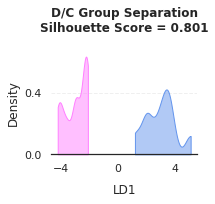

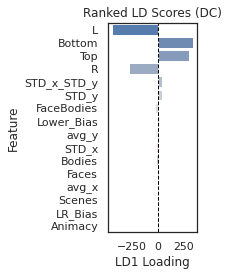

With Z-score Normalization of features

Silhouette Score DH (LDA): 0.924

lda_DH
                    LD1
L           -744.506117
R           -394.864432
Lower_Bias  -135.547217
avg_y        -23.997564
FaceBodies   -16.425220
Scenes       -16.289370
Animacy      -13.844010
STD_x         -7.635240
Bodies         1.676384
STD_y          6.029790
LR_Bias       11.128053
Faces         14.938194
STD_x_STD_y   16.570355
avg_x         32.428035
Top          270.297709
Bottom       611.332034


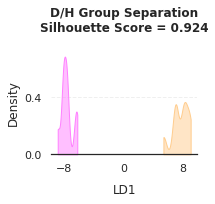

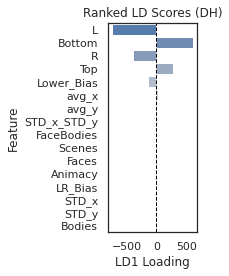

With Z-score Normalization of features

Silhouette Score HC (LDA): 0.906

lda_HC
                    LD1
Bottom      -411.486893
LR_Bias     -157.217656
Top          -92.189189
STD_y        -40.870732
STD_x_STD_y  -39.307400
Faces        -15.459929
Bodies         0.668506
avg_x          7.568494
Animacy       14.265318
STD_x         15.525912
Scenes        16.447352
avg_y         19.539884
FaceBodies    21.926251
Lower_Bias   256.325841
R            284.354633
L            521.265231


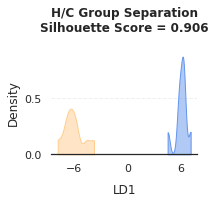

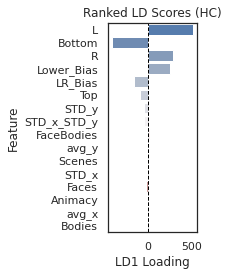

In [27]:
loadings_DC_full, lda_df_DC_full, sil_score_DC_full = two_groups_LDA(df_ET, 'D', 'C', print_loadings = 1,z_score_features=1, selected_features=[])
plot_lda_ridgeline(lda_df_DC_full, sil_score_DC_full, 'D', 'C', color1=custom_palette[2], color2=custom_palette[0],figsize=[3,3])
barplot_sorted_LD1(plotspath,loadings_DC_full, 'D', 'C',fig_size=[3,4])


loadings_DH_full, lda_df_DH_full, sil_score_DH_full = two_groups_LDA(df_ET, 'D', 'H', print_loadings = 1, z_score_features=1, selected_features=[])
plot_lda_ridgeline(lda_df_DH_full, sil_score_DH_full, 'D', 'H', color1=custom_palette[2], color2=custom_palette[1],figsize=[3,3])
barplot_sorted_LD1(plotspath,loadings_DH_full, 'D', 'H',fig_size=[3,4])


loadings_HC_full, lda_df_HC_full, sil_score_HC_full = two_groups_LDA(df_ET, 'H', 'C', print_loadings = 1,z_score_features=1,  selected_features=[])
plot_lda_ridgeline(lda_df_HC_full, sil_score_HC_full, 'H', 'C', color1=custom_palette[1], color2=custom_palette[0],figsize=[3,3])
barplot_sorted_LD1(plotspath,loadings_HC_full, 'H', 'C',fig_size=[3,4])


# Figure 5 // Panel F: Variable Coupling Relationships change across groups

In [28]:
def plot_coupling(plotspath, df, feat_x, feat_y, custom_palette_dict, group_order, pairs_to_compare): 
    
    g = sns.lmplot(data=df, x=feat_x, y=feat_y, hue='Group', palette=custom_palette_dict, 
                   hue_order=group_order, ci=95, scatter_kws={'alpha':0.5, 's':80}, 
                   line_kws={'linewidth':3}, height=4, aspect=1, legend=False)
    ax = g.ax
    stats_rows, delta_rows, results = [], [], {}

    # Within Group Stats
    for grp in group_order:
        g_df = df[df['Group'] == grp].dropna()
        res = smf.ols(f"{feat_y} ~ {feat_x}", data=g_df).fit()
        results[grp] = {'b': res.params[feat_x], 'r': g_df[feat_x].corr(g_df[feat_y])}
        stats_rows.append(f"{grp.upper()}: β={results[grp]['b']:.2f}, p={res.pvalues[1]:.3f}, R²={res.rsquared:.2f}")

    # Between Group Comparisons (Interaction + Bayes Factor)
    for g1, g2 in pairs_to_compare:
        sub_df = df[df['Group'].isin([g1, g2])]
        
        # calculate the Bayes Factor (BF10) using BIC testing the interaction (difference in slopes) 
        # comparing two models: m_null (No interaction) vs m_alt (Interaction)
        m_null = smf.ols(f"{feat_y} ~ {feat_x} + Group", data=sub_df).fit()
        m_alt  = smf.ols(f"{feat_y} ~ {feat_x} * Group", data=sub_df).fit()
        
        bf10 = np.exp((m_null.bic - m_alt.bic) / 2) 
        p_val = m_alt.pvalues[-1]
        db = results[g1]['b'] - results[g2]['b']
        
        # Label evidence strength based on BF10
        ev = " (Strong)" if bf10 > 10 else " (Moderate)" if bf10 > 3 else ""# "Weak"
        sig_star = " * " if p_val < 0.05 else "" #"ns"
        
        # Append arranged text to report stats on figure:
        delta_rows.append(f"Δ{g1}-{g2}: Δβ={db:.2f}, p={p_val:.2f}{sig_star}, BF₁₀={bf10:.1f}{ev}")

    # Add text reporting stats:   
    ax.legend(facecolor='white',title="Groups", bbox_to_anchor=(1.05, 1), loc='upper left')
    text_cfg = dict(transform=ax.transAxes, fontsize=9, fontweight='bold', verticalalignment='top')
    
    # Within Group stats in light box
    ax.text(1.05, 0.6, "Group-Specific Coupling:\n" + "\n".join(stats_rows), **text_cfg, 
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#fdfdfd", alpha=0.9, edgecolor='gray'))
    
    # Between Group stats in blue-ish box
    ax.text(1.05, 0.35, "Group Comparisons:\n" + "\n".join(delta_rows), **text_cfg, 
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f7ff", alpha=0.9, edgecolor='gray'))

    plt.title(f"Coupling: {feat_x} vs {feat_y}", fontsize=12)
    
    plt.savefig(f"{plotspath}Fig5_PanelF_Feature_Coupling_Stats_BF_{feat_x}_{feat_y}.png", dpi=300, bbox_inches='tight')
    plt.show()

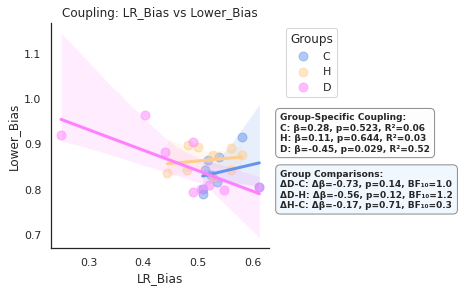

In [29]:
df = df_ET

pairs_to_compare = [('D', 'C'), ('D', 'H'), ('H', 'C')]

plot_coupling(plotspath, df, 'LR_Bias', 'Lower_Bias', custom_palette_dict, group_order, pairs_to_compare)

This can be repeated for all Feature couples, or only selected pairs. 
Template if we want to plot all possible pairs to learn about variable relations

In [24]:
# If you want to plot all feature combinations, uncomment: 

# from itertools import combinations

# for feat_x, feat_y in combinations(features, 2):
#     plot_coupling(plotspath, df, feat_x, feat_y, custom_palette_dict, group_order, pairs_to_compare)


# Extra: (all) Variable Coupling Differences 

First a subset of features:

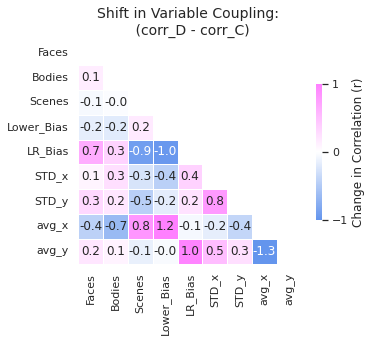

In [25]:
# Select a subset of features
subset_features = ['Faces', 'Bodies', 'Scenes', 'Lower_Bias', 'LR_Bias','STD_x', 'STD_y','avg_x', 'avg_y'] #features.columns.tolist() # ['Top', 'L', 'Faces', 'Scenes']


# Calculate change in coupling: (DS - Control)
corr_C = df[df['Group'] == 'C'][subset_features].corr()
corr_D = df[df['Group'] == 'D'][subset_features].corr()
diff_matrix = corr_D - corr_C

# Create mask for upper triangle
mask = np.triu(np.ones_like(diff_matrix, dtype=bool))

# Plot
plt.figure(figsize=(5, 5))
sns.heatmap(diff_matrix, 
    vmin=-1, vmax=1,
    mask=mask, 
    annot=True, fmt=".1f", 
    cmap=cmap_diverging_DC,
    center=0, square=True, linewidths=.5, 
    cbar_kws={"label": "Change in Correlation (r)", "ticks": [-1, 0, 1],"shrink": 0.5})

plt.title("Shift in Variable Coupling: \n (corr_D - corr_C)", fontsize=14)
plt.savefig(plotspath+"Bonus_Variable_Decoupling_matrix_DC_subset_" + str(np.datetime64('today')) + ".png",format='png',dpi=300, bbox_inches='tight')

plt.show()

### Decoupling matrix (DS - Controls) - All Features

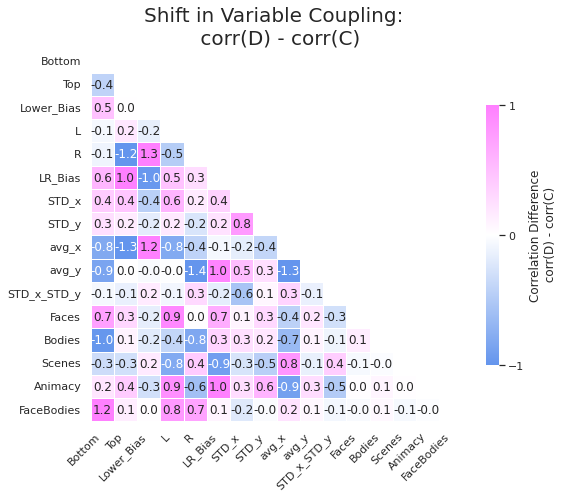

In [26]:
subset_features = features.columns.tolist() 

# Calculate the change in coupling: (DS - Control)
corr_C = df[df['Group'] == 'C'][subset_features].corr()
corr_D = df[df['Group'] == 'D'][subset_features].corr()
diff_matrix = corr_D - corr_C

# mask for upper triangle
mask = np.triu(np.ones_like(diff_matrix, dtype=bool))

# Plot
plt.figure(figsize=(8,8)) 
sns.set_style("white")

sns.heatmap(diff_matrix, 
    vmin=-1, vmax=1,
    mask=mask, annot=True, fmt=".1f", 
    cmap=cmap_diverging_DC, center=0, square=True, linewidths=.5, 
    cbar_kws={"label": "Correlation Difference\n corr(D) - corr(C)", "ticks": [-1, 0, 1],"shrink": 0.5})

sns.set_theme(rc={
    'axes.labelsize': 22,     # Size of x and y labels
    'xtick.labelsize': 18,    # Size of x-axis tick labels
    'ytick.labelsize': 18,    # Size of y-axis tick labels
    'axes.titlesize': 20})    # Size of the plot title


plt.xticks(rotation=45, ha='right')
plt.tight_layout() 

plt.title("Shift in Variable Coupling: \n corr(D) - corr(C)")
plt.savefig(plotspath+"Bonus_Variable_Decoupling_matrix_DC_allfeatures_" + str(np.datetime64('today')) + ".png",format='png',dpi=300, bbox_inches='tight')

plt.show()